1. Import Libraries

**Problem statement.**
How well can machine learning models use climate, soil, and agronomic data to predict maize yield in Rwanda, and what factors have the biggest effect on that yield?




**Data Description:** I got the data from Rwanda Agricultural Board and it contains rainfall, temperature, humidity, solar radiation, soil nutrient content, soil moisture, vegetation indices, fertilizer application, and plant density.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.model_selection import GridSearchCV

import shap
!pip install xgboost lightgbm
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

2. Rwanda Agricultural Dataset Generator

In [4]:
data_raw = pd.read_csv('/content/Maize_crop_yield_rwanda_dataset.csv')

In [7]:
data = data_raw.copy()
print(data.head())

         Date  Temperature   Rainfall   Humidity  SolarRadiation   Soil_pH  \
0  2025-08-02    23.223471  69.934283  76.139478       16.591577  6.359075   
1  2025-08-02    20.050164  21.734395  81.725190       17.322671  5.875085   
2  2025-08-02    24.251396  36.980128  61.538313       20.467635  5.859745   
3  2025-08-02    24.976933  63.937225  66.314890       21.171367  6.168547   
4  2025-08-02    24.723353  46.461560  77.804361       16.562477  6.512400   

      Soil_N     Soil_P     Soil_K  Soil_Moisture      NDVI  Fertilizer  \
0  60.230299  30.360926  36.126904       0.728632  0.636931   70.731646   
1  34.871689  34.199731  30.735807       0.338057  0.468580   51.505036   
2  42.083063  27.788054  52.818225       0.484226  0.449898   84.177272   
3  43.843517  29.892274  26.171824       0.583694  0.608993   44.739197   
4  54.312801  26.125477  35.526301       0.548871  0.530102   57.873301   

   Plant_Density  Crop_Yield  Agro_Zone_Central Plateau  \
0       4.534270   10

Show missing values

In [8]:
print('Missing values in each column:')
print(data.isnull().sum())

Missing values in each column:
Date                            0
Temperature                     0
Rainfall                        0
Humidity                        0
SolarRadiation                  0
Soil_pH                         0
Soil_N                          0
Soil_P                          0
Soil_K                          0
Soil_Moisture                   0
NDVI                            0
Fertilizer                      0
Plant_Density                   0
Crop_Yield                      0
Agro_Zone_Central Plateau       0
Agro_Zone_Eastern Savannah      0
Agro_Zone_Northern Highlands    0
Agro_Zone_Western Highlands     0
Satellite_NDVI                  0
dtype: int64


Droppeed Misssing values

In [25]:
# Drop rows with missing values
data_clean = data.dropna()
print(f"Original data shape: {data.shape}")
print(f"Cleaned data shape (after dropping NaNs): {data_clean.shape}")

Original data shape: (3150, 22)
Cleaned data shape (after dropping NaNs): (3150, 22)


Remove duplicates

In [28]:
print(data.duplicated().sum())

0


### Filter Outliers using IQR method

In [32]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_filtered

initial_rows_outlier = data_clean.shape[0]

# Identify numerical columns to check for outliers (excluding boolean 'Agro_Zone' columns)
numerical_cols = data_clean.select_dtypes(include=np.number).columns.tolist()
# Exclude 'Crop_Yield' if it's the target variable, and any boolean columns that might be treated as numbers
numerical_cols_for_outlier = [col for col in numerical_cols if not col.startswith('Agro_Zone_') and col != 'Crop_Yield']

data_no_outliers = data_clean.copy()

for col in numerical_cols_for_outlier:
    data_no_outliers = remove_outliers_iqr(data_no_outliers, col)

rows_removed_outlier = initial_rows_outlier - data_no_outliers.shape[0]

print(f"Original data_clean shape: {data_clean.shape}")
print(f"Data shape after outlier removal: {data_no_outliers.shape}")
print(f"Number of rows removed due to outliers: {rows_removed_outlier}")

data_clean = data_no_outliers.copy()

Original data_clean shape: (3150, 22)
Data shape after outlier removal: (2952, 22)
Number of rows removed due to outliers: 198


Data after removing ouliers

In [33]:
print('Descriptive statistics of the dataset after outlier removal:')
print(data_clean.describe())

Descriptive statistics of the dataset after outlier removal:
       Temperature     Rainfall     Humidity  SolarRadiation      Soil_pH  \
count  2952.000000  2952.000000  2952.000000     2952.000000  2952.000000   
mean     23.509596    95.079455    69.893142       18.040629     6.090951   
std       1.941996    46.247339     7.658814        2.904249     0.389223   
min      18.186452    -4.066912    48.638657        9.890303     4.997415   
25%      22.163404    58.136596    64.774515       15.939960     5.812271   
50%      23.540102    81.281778    70.108500       18.100139     6.092007   
75%      24.820145   134.158355    75.177908       20.061879     6.366932   
max      28.764764   231.220609    90.582019       25.943653     7.207349   

            Soil_N       Soil_P       Soil_K  Soil_Moisture         NDVI  \
count  2952.000000  2952.000000  2952.000000    2952.000000  2952.000000   
mean     44.996457    32.128448    37.768426       0.683902     0.678728   
std       9.72343

### Correlation Matrix for Selected Features

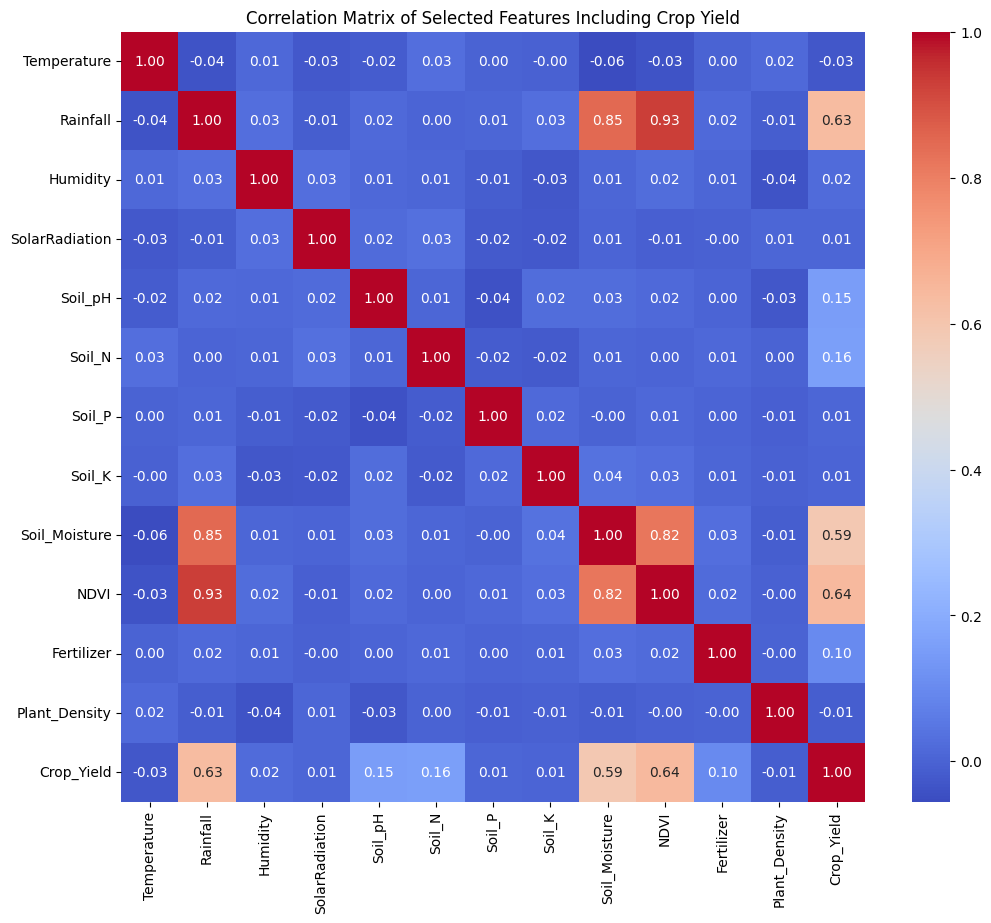

In [45]:
X_with_y = pd.concat([X, y], axis=1)

plt.figure(figsize=(12, 10))
sns.heatmap(X_with_y.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Selected Features Including Crop Yield")
plt.show()

### Feature Selection and Scaling

Satellite NDVI

 Dataset Segmentation

In [48]:
X_train,X_temp,y_train,y_temp=train_test_split(
    X_scaled,y,test_size=0.3,random_state=42)

X_val,X_test,y_val,y_test=train_test_split(
    X_temp,y_temp,test_size=0.5,random_state=42)

Model Training

In [49]:
models = {

"Linear Regression": LinearRegression(),

"Decision Tree": DecisionTreeRegressor(),

"Random Forest": RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
),

"Gradient Boosting": GradientBoostingRegressor(),

"XGBoost": XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6
),

"LightGBM": LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05
)

}

results={}
predictions={}

for name,model in models.items():

    model.fit(X_train,y_train)

    preds=model.predict(X_test)

    predictions[name]=preds

    rmse=np.sqrt(mean_squared_error(y_test,preds))
    r2=r2_score(y_test,preds)
    mae=mean_absolute_error(y_test,preds)

    results[name]=[rmse,r2,mae]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000572 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3060
[LightGBM] [Info] Number of data points in the train set: 2066, number of used features: 12
[LightGBM] [Info] Start training from score 9.331760


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


 Model Comparison

In [51]:
results_df=pd.DataFrame(results,
                        index=["RMSE","R2","MAE"]).T

print(results_df)

                       RMSE        R2       MAE
Linear Regression  1.688310  0.450497  1.311012
Decision Tree      2.429127 -0.137538  1.880634
Random Forest      1.711909  0.435028  1.339014
Gradient Boosting  1.719845  0.429778  1.343093
XGBoost            1.741876  0.415076  1.349909
LightGBM           1.719617  0.429929  1.334054


In [57]:
results_df=pd.DataFrame(results,
                        index=["RMSE","R2","MAE"]).T

best_model_name = results_df['RMSE'].idxmin()
best_model = models[best_model_name]

print(f"The best performing model (lowest RMSE) is: {best_model_name}")

The best performing model (lowest RMSE) is: Linear Regression


Visualization

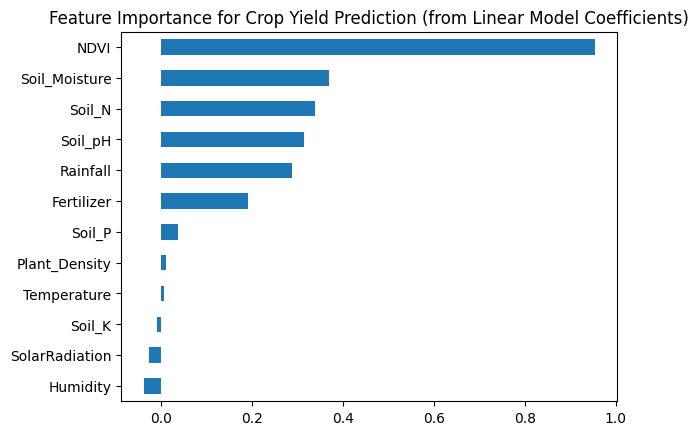

In [ ]:
if hasattr(best_model, 'feature_importances_'):
    importance = pd.Series(best_model.feature_importances_, index=X.columns)
    title_suffix = " (from Tree-based Model)"
elif hasattr(best_model, 'coef_'):
    importance = pd.Series(best_model.coef_, index=X.columns)
    title_suffix = " (from Linear Model Coefficients)"
else:
    importance = pd.Series([]) # Fallback
    title_suffix = ""

if not importance.empty:
    importance.sort_values().plot(kind="barh")
    plt.title(f"Feature Importance for Crop Yield Prediction{title_suffix}")
    plt.show()
else:
    print("Feature importance could not be determined for the selected model.")

Conclusion : 
This shows that vegetation health and water-related factors largely influence maize yield and NDVI, rainfall and soil moisture are the most important predictors. The analysis also shows that crop productivity is governed by multiple variables interacting in a complex way, rather than by any single dominant factor.
